In [2]:
# import and install
import cv2
import matplotlib.pyplot as plt
import torch

In [3]:
# setup sam
CHECKPOINT_PATH = "../models/sam_vit_b_01ec64.pth"
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_b"
print(MODEL_TYPE)
print(CHECKPOINT_PATH)

vit_b
../models/sam_vit_b_01ec64.pth


In [4]:
# why did kernel die :(
import os

print(CHECKPOINT_PATH)
print(os.path.exists(CHECKPOINT_PATH))
print(os.path.getsize(CHECKPOINT_PATH) / (1024**3), "GB")

../models/sam_vit_b_01ec64.pth
True
0.34928543772548437 GB


C:\Users\fiona\AppData\Local\Temp\ipykernel_29332\3382519697.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  points = plt.ginput(n=5, timeout=0, show_clicks=True)


KeyboardInterrupt: 

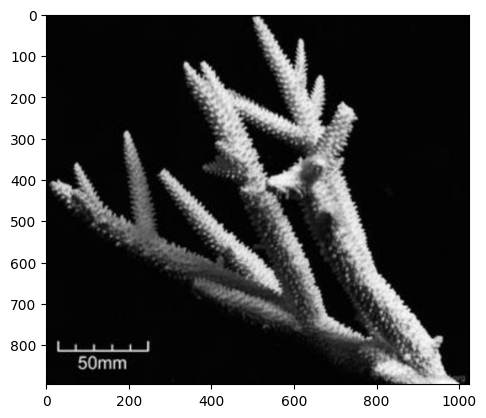

In [7]:
# resize image
image = cv2.imread("../data/raw/arborescent/intermedia1.jpg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
height, width = rgb.shape[:2]
scale = 1024/width
rgb = cv2.resize(rgb, (1024, (int)(height * scale)))

# get points
fig, ax = plt.subplots()
ax.imshow(rgb)
points = plt.ginput(n=5, timeout=0, show_clicks=True)

In [ ]:
# create mask generator
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)
predictor = SamPredictor(sam)
#mask_generator = SamAutomaticMaskGenerator(
#    model=sam,
#    points_per_side=16,
#    pred_iou_thresh=0.7,
#    stability_score_thresh=0.85,
#    min_mask_region_area=500
#)

In [ ]:
# point prompting
predictor.set_image(rgb)


In [51]:
# test mask generation on intermedia1.jpg
output_mask = mask_generator.generate(rgb)
print(len(output_mask)) # # of masks


57


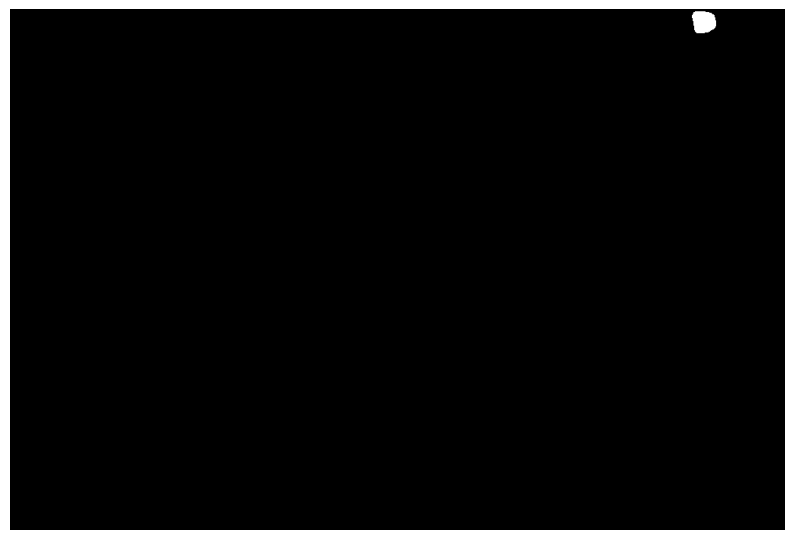

In [48]:
# view one mask
mask = output_mask[0]["segmentation"]

plt.figure(figsize=(10,10))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

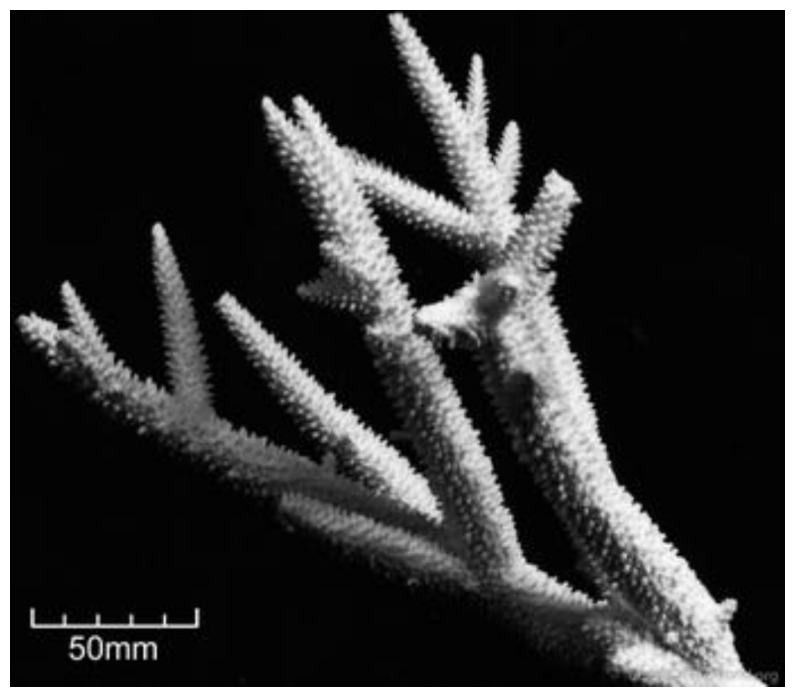

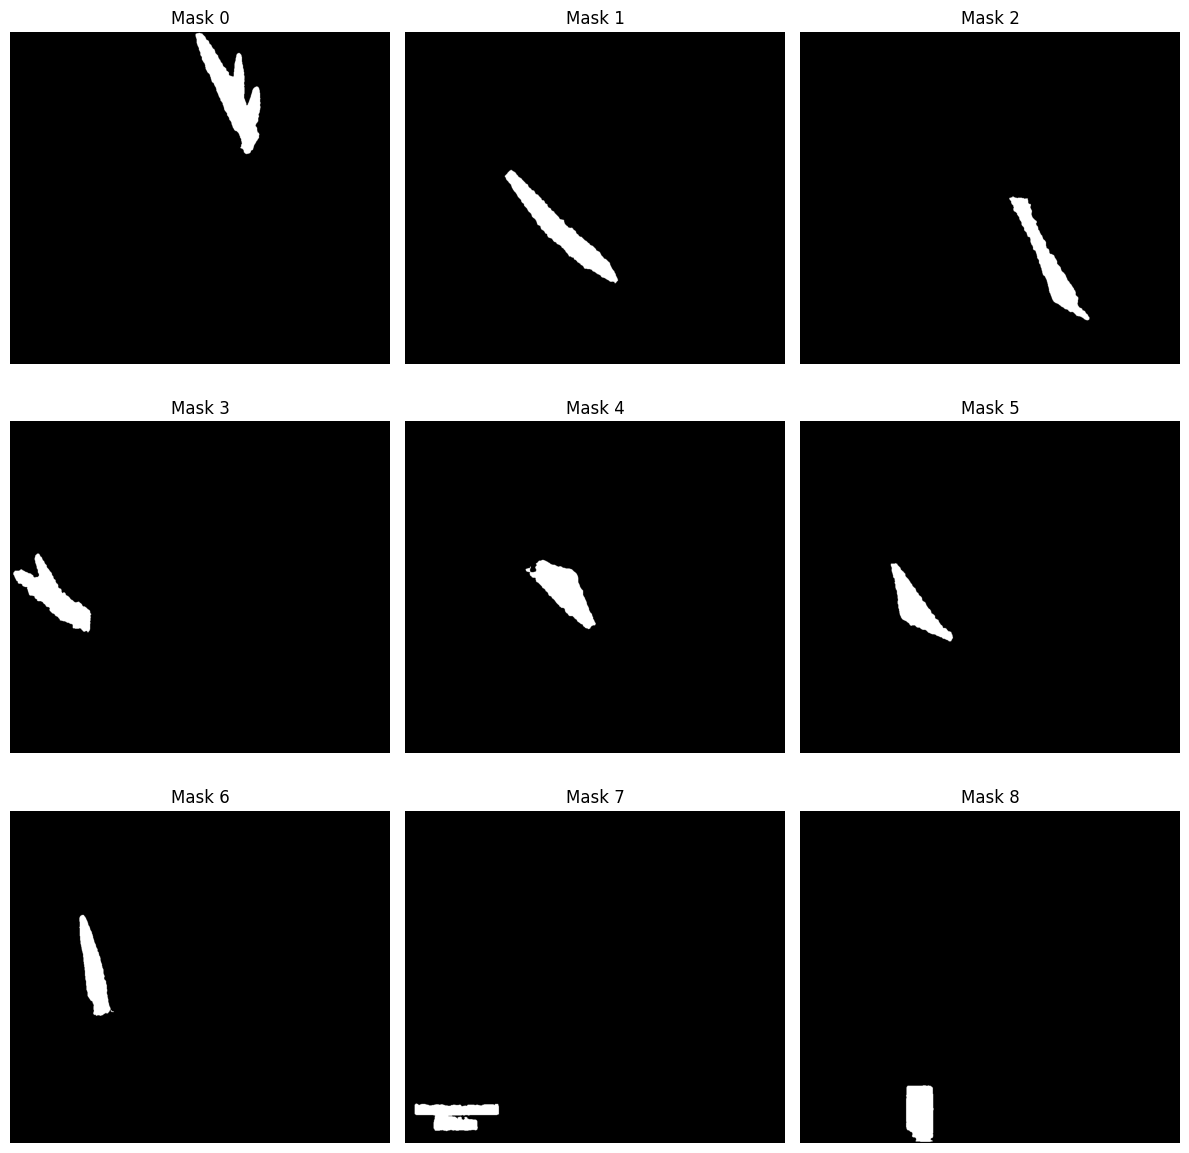

In [52]:
# view masks together 9 at a time
# original
plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.axis('off')
# sort mask greatest -> least area
sorted_masks = sorted(
    output_mask,
    key=lambda x: x["area"],
    reverse=True
)

# masks
start = 0
end = 9
fig, axes = plt.subplots(3, 3, figsize=(12,12))
axes = axes.flatten()
for j, ax in enumerate(axes):
    i = start + j 
    if i < end:
        mask = sorted_masks[i]['segmentation']
        ax.imshow(mask, cmap='gray')
        ax.set_title(f'Mask {i}')
    ax.axis('off')
plt.tight_layout() # no overlap
plt.show()